In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.signal import butter, cheby1, cheby2, ellip, freqz

In [2]:
# Filterparameter

# Ordnung
order = 2
order_b = 6

# Abtastfrequenz für Audioanwendungen
fs = 44100

# Grenzfrequenz für Tief- und Hochpass
fc = 1000
# Normalisiert Grenzfrequenz
wn = fc / (fs/2)

#Untere und obere Grenzen für Bandpass und Bandsperre
low = 300
high = 3400
# Normalisierte untere und obere Grenzfrequenz
wn_b = [low/(fs/2), high/(fs/2)]

# Ripple und Dämpung des Durchlass- und Sperrbereichs
rp = 0.5
rs = 90

In [3]:
# Butter Tiefpass Filterentwurf
b_lp_bw, a_lp_bw = butter(N=order, Wn=wn, btype='low', analog=False)
z_lp_bw, p_lp_bw, k_lp_bw = butter(N=order, Wn=wn, btype='low', analog=False, output='zpk')
sos_lp_bw = butter(N=order, Wn=wn, btype='low', analog=False, output='sos')

# Frequenzgang berechnen
w_lp_bw, h_lp_bw = freqz(b_lp_bw, a_lp_bw, worN=1024, fs=fs)

# Koeffizienten
print('Butterworth-Tiefpass')
print('b Koeffizienten:', b_lp_bw)
print('a Koeffizienten:', a_lp_bw)
print('SOS-Matrix:')
for i, section in enumerate(sos_lp_bw):
    print(f"Section {i + 1}: {section}")

Butterworth-Tiefpass
b Koeffizienten: [0.004604 0.009208 0.004604]
a Koeffizienten: [ 1.         -1.79909641  0.8175124 ]
SOS-Matrix:
Section 1: [ 0.004604    0.009208    0.004604    1.         -1.79909641  0.8175124 ]


In [4]:
# Cheby1 Tiefpass Filterentwurf
b_lp_c1, a_lp_c1 = cheby1(N=order, rp=rp, Wn=wn, btype='low', analog=False)
z_lp_c1, p_lp_c1, k_lp_c1 = cheby1(N=order, rp=rp, Wn=wn, btype='low', analog=False, output='zpk')
sos_lp_c1 = cheby1(N=order, rp=rp, Wn=wn, btype='low', analog=False, output='sos')

# Frequenzgang berechnen
w_lp_c1, h_lp_c1 = freqz(b_lp_c1, a_lp_c1, worN=1024, fs=fs)

# Koeffizienten
print('Chebyshev1-Tiefpass')
print('b Koeffizienten:', b_lp_c1)
print('a Koeffizienten:', a_lp_c1)
print('SOS-Matrix:')
for i, section in enumerate(sos_lp_c1):
    print(f"Section {i + 1}: {section}")

Chebyshev1-Tiefpass
b Koeffizienten: [0.00656966 0.01313931 0.00656966]
a Koeffizienten: [ 1.         -1.78877508  0.81661081]
SOS-Matrix:
Section 1: [ 0.00656966  0.01313931  0.00656966  1.         -1.78877508  0.81661081]


In [5]:
# Cheby2 Tiefpass Filterentwurf
b_lp_c2, a_lp_c2 = cheby2(N=order, rs=rs, Wn=wn, btype='low', analog=False)
z_lp_c2, p_lp_c2, k_lp_c2 = cheby2(N=order, rs=rs, Wn=wn, btype='low', analog=False, output='zpk')
sos_lp_c2 = cheby2(N=order, rs=rs, Wn=wn, btype='low', analog=False, output='sos')

# Frequenzgang berechnen
w_lp_c2, h_lp_c2 = freqz(b_lp_c2, a_lp_c2, worN=1024, fs=fs)

# Koeffizienten
print('Chebyshev2-Tiefpass')
print('b Koeffizienten:', b_lp_c2)
print('a Koeffizienten:', a_lp_c2)
print('SOS-Matrix:')
for i, section in enumerate(sos_lp_c2):
    print(f"Section {i + 1}: {section}")

Chebyshev2-Tiefpass
b Koeffizienten: [ 1.01003996e-06 -1.97934925e-06  1.01003996e-06]
a Koeffizienten: [ 1.         -1.99971457  0.99971461]
SOS-Matrix:
Section 1: [ 1.01003996e-06 -1.97934925e-06  1.01003996e-06  1.00000000e+00
 -1.99971457e+00  9.99714606e-01]


In [6]:
# Ellip Tiefpass Filterentwurf
b_lp_ep, a_lp_ep = ellip(N=order, rp=rp, rs=rs, Wn=wn, btype='low', analog=False)
z_lp_ep, p_lp_ep, k_lp_ep = ellip(N=order, rp=rp, rs=rs, Wn=wn, btype='low', analog=False, output='zpk')
sos_lp_ep = ellip(N=order, rp=rp, rs=rs, Wn=wn, btype='low', analog=False, output='sos')

# Frequenzgang berechnen
w_lp_ep, h_lp_ep = freqz(b_lp_ep, a_lp_ep, worN=1024, fs=fs)

# Koeffizienten
print('Elliptischer Tiefpass')
print('b Koeffizienten:', b_lp_ep)
print('a Koeffizienten:', a_lp_ep)
print('SOS-Matrix:')
for i, section in enumerate(sos_lp_ep):
    print(f"Section {i + 1}: {section}")

Elliptischer Tiefpass
b Koeffizienten: [0.00657056 0.01313751 0.00657056]
a Koeffizienten: [ 1.         -1.78877516  0.8166109 ]
SOS-Matrix:
Section 1: [ 0.00657056  0.01313751  0.00657056  1.         -1.78877516  0.8166109 ]


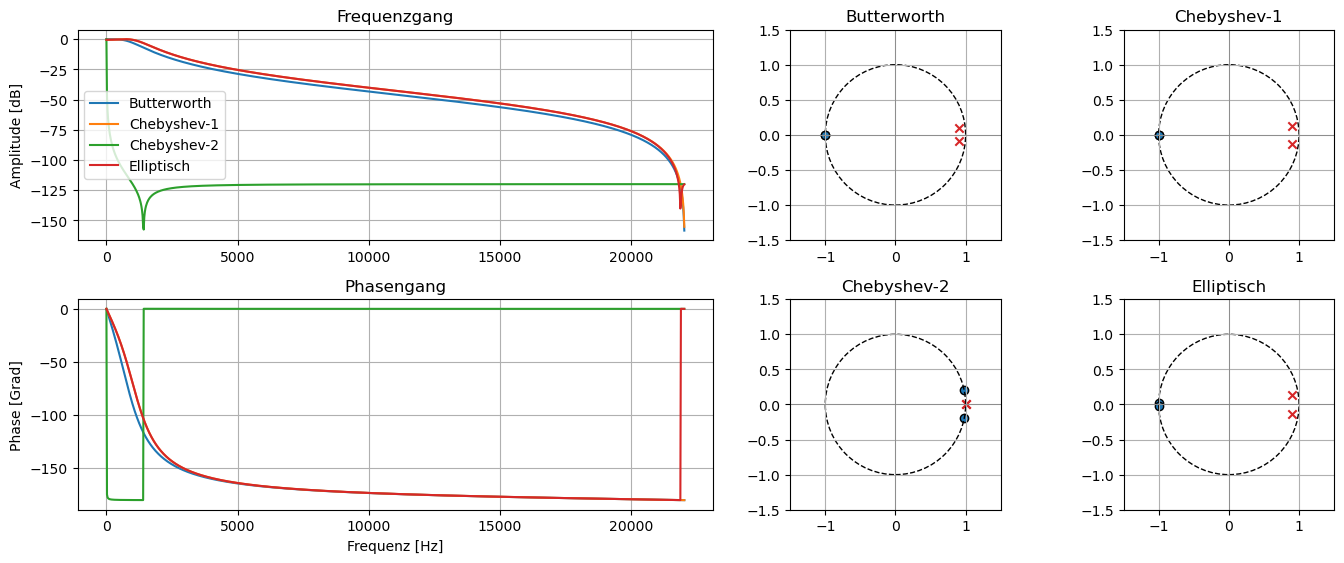

In [7]:
# Plot: Tiefpassvergleich
fig_lp = plt.figure(figsize=(14, 8))
gs_lp = fig_lp.add_gridspec(3, 4)

ax_mag_lp = fig_lp.add_subplot(gs_lp[0, :2])
ax_phase_lp = fig_lp.add_subplot(gs_lp[1, :2], sharex=ax_mag_lp)

# Subplots für Pol-/Nullstellen (2x2 rechts oben)
ax_pz1_lp = fig_lp.add_subplot(gs_lp[0, 2])
ax_pz2_lp = fig_lp.add_subplot(gs_lp[0, 3])
ax_pz3_lp = fig_lp.add_subplot(gs_lp[1, 2])
ax_pz4_lp = fig_lp.add_subplot(gs_lp[1, 3])

ax_mag_lp.plot(w_lp_bw, 20 * np.log10(np.maximum(np.abs(h_lp_bw),1e-10)), label='Butterworth')
ax_phase_lp.plot(w_lp_bw, np.unwrap(np.angle(h_lp_bw))*(180/np.pi), label = 'Butterworth')
ax_pz1_lp.scatter(np.real(z_lp_bw), np.imag(z_lp_bw), marker='o', edgecolor='k', facecolor='tab:blue')
ax_pz1_lp.scatter(np.real(p_lp_bw), np.imag(p_lp_bw), marker='x', color='tab:red')
ax_pz1_lp.add_patch(patches.Circle((0, 0), 1, fill=False, color='black', linestyle='--'))
ax_pz1_lp.set_title("Butterworth")

ax_mag_lp.plot(w_lp_c1, 20 * np.log10(np.maximum(np.abs(h_lp_c1),1e-10)), label='Chebyshev-1')
ax_phase_lp.plot(w_lp_c1, np.unwrap(np.angle(h_lp_c1))*(180/np.pi), label = 'Chebyshev-1')
ax_pz2_lp.scatter(np.real(z_lp_c1), np.imag(z_lp_c1), marker='o', edgecolor='k', facecolor='tab:blue')
ax_pz2_lp.scatter(np.real(p_lp_c1), np.imag(p_lp_c1), marker='x', color='tab:red')
ax_pz2_lp.add_patch(patches.Circle((0, 0), 1, fill=False, color='black', linestyle='--'))
ax_pz2_lp.set_title("Chebyshev-1")

ax_mag_lp.plot(w_lp_c2, 20 * np.log10(np.maximum(np.abs(h_lp_c2),1e-10)), label='Chebyshev-2')
ax_phase_lp.plot(w_lp_c2, np.unwrap(np.angle(h_lp_c2))*(180/np.pi), label = 'Chebyshev-2')
ax_pz3_lp.scatter(np.real(z_lp_c2), np.imag(z_lp_c2), marker='o', edgecolor='k', facecolor='tab:blue')
ax_pz3_lp.scatter(np.real(p_lp_c2), np.imag(p_lp_c2), marker='x', color='tab:red')
ax_pz3_lp.add_patch(patches.Circle((0, 0), 1, fill=False, color='black', linestyle='--'))
ax_pz3_lp.set_title("Chebyshev-2")

ax_mag_lp.plot(w_lp_ep, 20 * np.log10(np.maximum(np.abs(h_lp_ep),1e-10)), label='Elliptisch')
ax_phase_lp.plot(w_lp_ep, np.unwrap(np.angle(h_lp_ep))*(180/np.pi), label = 'Elliptisch')
ax_pz4_lp.scatter(np.real(z_lp_ep), np.imag(z_lp_ep), marker='o', edgecolor='k', facecolor='tab:blue')
ax_pz4_lp.scatter(np.real(p_lp_ep), np.imag(p_lp_ep), marker='x', color='tab:red')
ax_pz4_lp.add_patch(patches.Circle((0, 0), 1, fill=False, color='black', linestyle='--'))
ax_pz4_lp.set_title("Elliptisch")

# Einstellungen für alle Subplots
for ax_lp in [ax_pz1_lp, ax_pz2_lp, ax_pz3_lp, ax_pz4_lp]:
    ax_lp.axhline(0, color='gray', lw=0.5)
    ax_lp.axvline(0, color='gray', lw=0.5)
    ax_lp.set_xlim([-1.5, 1.5])
    ax_lp.set_ylim([-1.5, 1.5])
    ax_lp.set_aspect('equal')
    ax_lp.grid(True)

# Frequenz- und Phasengang
ax_mag_lp.set_title("Frequenzgang")
ax_mag_lp.set_ylabel("Amplitude [dB]")
ax_mag_lp.grid(True)
ax_mag_lp.legend()

ax_phase_lp.set_title("Phasengang")
ax_phase_lp.set_ylabel("Phase [Grad]")
ax_phase_lp.set_xlabel("Frequenz [Hz]")
ax_phase_lp.grid(True)

plt.tight_layout()
plt.show()

In [8]:
# Butter Hochpass Filterentwurf
b_hp_bw, a_hp_bw = butter(N=order, Wn=wn, btype='high', analog=False)
z_hp_bw, p_hp_bw, k_hp_bw = butter(N=order, Wn=wn, btype='high', analog=False, output='zpk')
sos_hp_bw = butter(N=order, Wn=wn, btype='high', analog=False, output='sos')

# Frequenzgang berechnen
w_hp_bw, h_hp_bw = freqz(b_hp_bw, a_hp_bw, worN=1024, fs=fs)

# Koeffizienten
print('Butterworth-Hochpass')
print('b Koeffizienten:', b_hp_bw)
print('a Koeffizienten:', a_hp_bw)
print('SOS-Matrix:')
for i, section in enumerate(sos_hp_bw):
    print(f"Section {i + 1}: {section}")

Butterworth-Hochpass
b Koeffizienten: [ 0.9041522  -1.80830441  0.9041522 ]
a Koeffizienten: [ 1.         -1.79909641  0.8175124 ]
SOS-Matrix:
Section 1: [ 0.9041522  -1.80830441  0.9041522   1.         -1.79909641  0.8175124 ]


In [9]:
# Cheby1 Hochpass Filterentwurf
b_hp_c1, a_hp_c1 = cheby1(N=order, rp=rp, Wn=wn, btype='high', analog=False)
z_hp_c1, p_hp_c1, k_hp_c1 = cheby1(N=order, rp=rp, Wn=wn, btype='high', analog=False, output='zpk')
sos_hp_c1 = cheby1(N=order, rp=rp, Wn=wn, btype='high', analog=False, output='sos')

# Frequenzgang berechnen
w_hp_c1, h_hp_c1 = freqz(b_hp_c1, a_hp_c1, worN=1024, fs=fs)

# Koeffizienten
print('Chebyshev1-Hochpass')
print('b Koeffizienten:', b_hp_c1)
print('a Koeffizienten:', a_hp_c1)
print('SOS-Matrix:')
for i, section in enumerate(sos_hp_c1):
    print(f"Section {i + 1}: {section}")

Chebyshev1-Hochpass
b Koeffizienten: [ 0.88192557 -1.76385114  0.88192557]
a Koeffizienten: [ 1.         -1.86209112  0.87464067]
SOS-Matrix:
Section 1: [ 0.88192557 -1.76385114  0.88192557  1.         -1.86209112  0.87464067]


In [10]:
# Cheby2 Hochpass Filterentwurf
b_hp_c2, a_hp_c2 = cheby2(N=order, rs=rs, Wn=wn, btype='high', analog=False)
z_hp_c2, p_hp_c2, k_hp_c2 = cheby2(N=order, rs=rs, Wn=wn, btype='high', analog=False, output='zpk')
sos_hp_c2 = cheby2(N=order, rs=rs, Wn=wn, btype='high', analog=False, output='sos')

# Frequenzgang berechnen
w_hp_c2, h_hp_c2 = freqz(b_hp_c2, a_hp_c2, worN=1024, fs=fs)

# Koeffizienten
print('Chebyshev2-Hochpass')
print('b Koeffizienten:', b_hp_c2)
print('a Koeffizienten:', a_hp_c2)
print('SOS-Matrix:')
for i, section in enumerate(sos_hp_c2):
    print(f"Section {i + 1}: {section}")

Chebyshev2-Hochpass
b Koeffizienten: [ 0.00038289 -0.00076188  0.00038289]
a Koeffizienten: [1.         1.94396659 0.94549424]
SOS-Matrix:
Section 1: [ 3.82886542e-04 -7.61883624e-04  3.82886542e-04  1.00000000e+00
  1.94396659e+00  9.45494243e-01]


In [11]:
# Ellip Hochpass Filterentwurf
b_hp_ep, a_hp_ep = ellip(N=order, rp=rp, rs=rs, Wn=wn, btype='high', analog=False)
z_hp_ep, p_hp_ep, k_hp_ep = ellip(N=order, rp=rp, rs=rs, Wn=wn, btype='high', analog=False, output='zpk')
sos_hp_ep = ellip(N=order, rp=rp, rs=rs, Wn=wn, btype='high', analog=False, output='sos')

# Frequenzgang berechnen
w_hp_ep, h_hp_ep = freqz(b_hp_ep, a_hp_ep, worN=1024, fs=fs)

# Koeffizienten
print('Elliptischer Hochpass')
print('b Koeffizienten:', b_hp_ep)
print('a Koeffizienten:', a_hp_ep)
print('SOS-Matrix:')
for i, section in enumerate(sos_hp_ep):
    print(f"Section {i + 1}: {section}")

Elliptischer Hochpass
b Koeffizienten: [ 0.88192562 -1.76385124  0.88192562]
a Koeffizienten: [ 1.         -1.86209122  0.87464078]
SOS-Matrix:
Section 1: [ 0.88192562 -1.76385124  0.88192562  1.         -1.86209122  0.87464078]


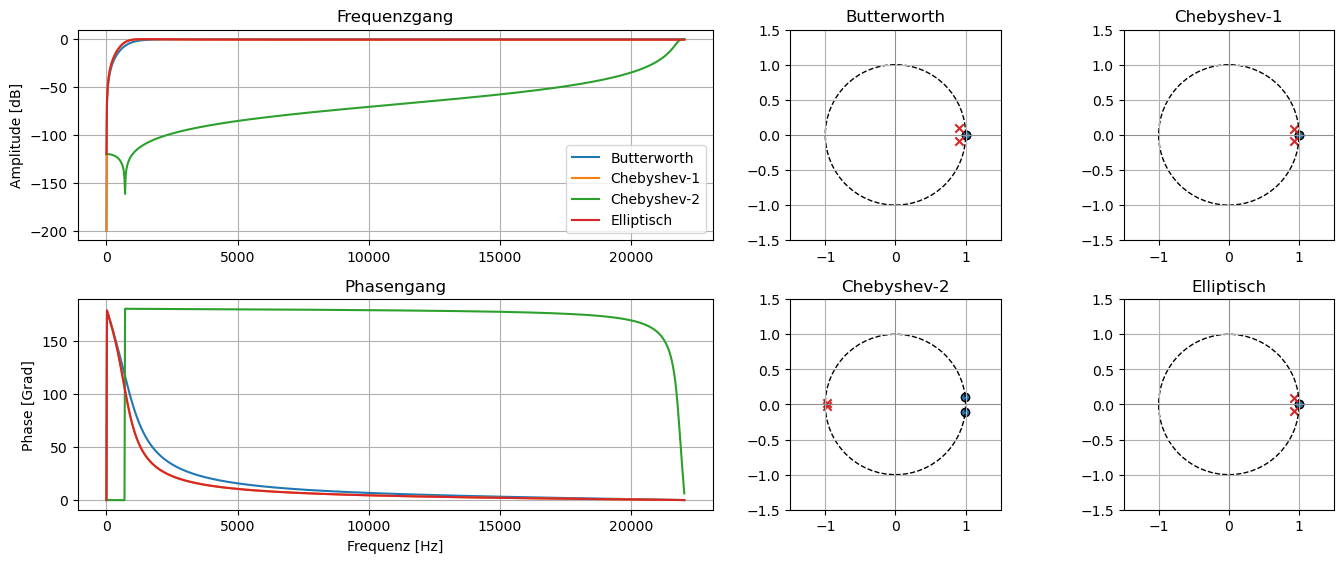

In [12]:
# Plot: Hochpassvergleich
fig_hp = plt.figure(figsize=(14, 8))
gs_hp = fig_hp.add_gridspec(3, 4)

ax_mag_hp = fig_hp.add_subplot(gs_hp[0, :2])
ax_phase_hp = fig_hp.add_subplot(gs_hp[1, :2], sharex=ax_mag_hp)

# Subplots für Pol-/Nullstellen (2x2 rechts oben)
ax_pz1_hp = fig_hp.add_subplot(gs_hp[0, 2])
ax_pz2_hp = fig_hp.add_subplot(gs_hp[0, 3])
ax_pz3_hp = fig_hp.add_subplot(gs_hp[1, 2])
ax_pz4_hp = fig_hp.add_subplot(gs_hp[1, 3])

ax_mag_hp.plot(w_hp_bw, 20 * np.log10(np.maximum(np.abs(h_hp_bw),1e-10)), label='Butterworth')
ax_phase_hp.plot(w_hp_bw, np.unwrap(np.angle(h_hp_bw))*(180/np.pi), label = 'Butterworth')
ax_pz1_hp.scatter(np.real(z_hp_bw), np.imag(z_hp_bw), marker='o', edgecolor='k', facecolor='tab:blue')
ax_pz1_hp.scatter(np.real(p_hp_bw), np.imag(p_hp_bw), marker='x', color='tab:red')
ax_pz1_hp.add_patch(patches.Circle((0, 0), 1, fill=False, color='black', linestyle='--'))
ax_pz1_hp.set_title("Butterworth")

ax_mag_hp.plot(w_hp_c1, 20 * np.log10(np.maximum(np.abs(h_hp_c1),1e-10)), label='Chebyshev-1')
ax_phase_hp.plot(w_hp_c1, np.unwrap(np.angle(h_hp_c1))*(180/np.pi), label = 'Chebyshev-1')
ax_pz2_hp.scatter(np.real(z_hp_c1), np.imag(z_hp_c1), marker='o', edgecolor='k', facecolor='tab:blue')
ax_pz2_hp.scatter(np.real(p_hp_c1), np.imag(p_hp_c1), marker='x', color='tab:red')
ax_pz2_hp.add_patch(patches.Circle((0, 0), 1, fill=False, color='black', linestyle='--'))
ax_pz2_hp.set_title("Chebyshev-1")

ax_mag_hp.plot(w_hp_c2, 20 * np.log10(np.maximum(np.abs(h_hp_c2),1e-10)), label='Chebyshev-2')
ax_phase_hp.plot(w_hp_c2, np.unwrap(np.angle(h_hp_c2))*(180/np.pi), label = 'Chebyshev-2')
ax_pz3_hp.scatter(np.real(z_hp_c2), np.imag(z_hp_c2), marker='o', edgecolor='k', facecolor='tab:blue')
ax_pz3_hp.scatter(np.real(p_hp_c2), np.imag(p_hp_c2), marker='x', color='tab:red')
ax_pz3_hp.add_patch(patches.Circle((0, 0), 1, fill=False, color='black', linestyle='--'))
ax_pz3_hp.set_title("Chebyshev-2")

ax_mag_hp.plot(w_hp_ep, 20 * np.log10(np.maximum(np.abs(h_hp_ep),1e-10)), label='Elliptisch')
ax_phase_hp.plot(w_hp_ep, np.unwrap(np.angle(h_hp_ep))*(180/np.pi), label = 'Elliptisch')
ax_pz4_hp.scatter(np.real(z_hp_ep), np.imag(z_hp_ep), marker='o', edgecolor='k', facecolor='tab:blue')
ax_pz4_hp.scatter(np.real(p_hp_ep), np.imag(p_hp_ep), marker='x', color='tab:red')
ax_pz4_hp.add_patch(patches.Circle((0, 0), 1, fill=False, color='black', linestyle='--'))
ax_pz4_hp.set_title("Elliptisch")

# Einstellungen für alle Subplots
for ax_hp in [ax_pz1_hp, ax_pz2_hp, ax_pz3_hp, ax_pz4_hp]:
    ax_hp.axhline(0, color='gray', lw=0.5)
    ax_hp.axvline(0, color='gray', lw=0.5)
    ax_hp.set_xlim([-1.5, 1.5])
    ax_hp.set_ylim([-1.5, 1.5])
    ax_hp.set_aspect('equal')
    ax_hp.grid(True)

# Frequenz- und Phasengang
ax_mag_hp.set_title("Frequenzgang")
ax_mag_hp.set_ylabel("Amplitude [dB]")
ax_mag_hp.grid(True)
ax_mag_hp.legend()

ax_phase_hp.set_title("Phasengang")
ax_phase_hp.set_ylabel("Phase [Grad]")
ax_phase_hp.set_xlabel("Frequenz [Hz]")
ax_phase_hp.grid(True)

plt.tight_layout()
plt.show()

In [13]:
# Butter Bandpass Filterentwurf
b_bp_bw, a_bp_bw = butter(N=order_b, Wn=wn_b, btype='bandpass', analog=False)
z_bp_bw, p_bp_bw, k_bp_bw = butter(N=order_b, Wn=wn_b, btype='bandpass', analog=False, output='zpk')
sos_bp_bw = butter(N=order_b, Wn=wn_b, btype='bandpass', analog=False, output='sos')

# Frequenzgang berechnen
w_bp_bw, h_bp_bw = freqz(b_bp_bw, a_bp_bw, worN=1024, fs=fs)

# Koeffizienten
print('Butterworth-Bandpass')
print('b Koeffizienten:', b_bp_bw)
print('a Koeffizienten:', a_bp_bw)
print('SOS-Matrix:')
for i, section in enumerate(sos_bp_bw):
    print(f"Section {i + 1}: {section}")

Butterworth-Bandpass
b Koeffizienten: [ 0.00013737  0.         -0.00082424  0.          0.0020606   0.
 -0.00274747  0.          0.0020606   0.         -0.00082424  0.
  0.00013737]
a Koeffizienten: [ 1.00000000e+00 -9.84346993e+00  4.45777233e+01 -1.22866900e+02
  2.29638401e+02 -3.06691958e+02  3.00182773e+02 -2.16986283e+02
  1.14973093e+02 -4.35515709e+01  1.11949851e+01 -1.75331379e+00
  1.26521229e-01]
SOS-Matrix:
Section 1: [ 1.37373303e-04  2.74746605e-04  1.37373303e-04  1.00000000e+00
 -1.21671148e+00  3.80364908e-01]
Section 2: [ 1.          2.          1.          1.         -1.29346055  0.5040771 ]
Section 3: [ 1.          2.          1.          1.         -1.50645476  0.78464653]
Section 4: [ 1.         -2.          1.          1.         -1.90714666  0.90952103]
Section 5: [ 1.         -2.          1.          1.         -1.94072539  0.94274752]
Section 6: [ 1.         -2.          1.          1.         -1.97897111  0.98080753]


In [14]:
# Cheby1 Bandpass Filterentwurf
b_bp_c1, a_bp_c1 = cheby1(N=order_b, rp=rp, Wn=wn_b, btype='bandpass', analog=False)
z_bp_c1, p_bp_c1, k_bp_c1 = cheby1(N=order_b, rp=rp, Wn=wn_b, btype='bandpass', analog=False, output='zpk')
sos_bp_c1 = cheby1(N=order_b, rp=rp, Wn=wn_b, btype='bandpass', analog=False, output='sos')

# Frequenzgang berechnen
w_bp_c1, h_bp_c1 = freqz(b_bp_c1, a_bp_c1, worN=1024, fs=fs)

# Koeffizienten
print('Chebychev1-Bandpass')
print('b Koeffizienten:', b_bp_c1)
print('a Koeffizienten:', a_bp_c1)
print('SOS-Matrix:')
for i, section in enumerate(sos_bp_c1):
    print(f"Section {i + 1}: {section}")

Chebychev1-Bandpass
b Koeffizienten: [ 2.28951360e-05  0.00000000e+00 -1.37370816e-04  0.00000000e+00
  3.43427040e-04  0.00000000e+00 -4.57902720e-04  0.00000000e+00
  3.43427040e-04  0.00000000e+00 -1.37370816e-04  0.00000000e+00
  2.28951360e-05]
a Koeffizienten: [ 1.00000000e+00 -1.08677020e+01  5.45782350e+01 -1.67534331e+02
  3.50168635e+02 -5.25108119e+02  5.79377317e+02 -4.73947185e+02
  2.85293950e+02 -1.23243270e+02  3.62658658e+01 -6.52659717e+00
  5.43200964e-01]
SOS-Matrix:
Section 1: [ 2.28951360e-05  4.57902720e-05  2.28951360e-05  1.00000000e+00
 -1.73737995e+00  7.97080332e-01]
Section 2: [ 1.          2.          1.          1.         -1.63468254  0.82155832]
Section 3: [ 1.          2.          1.          1.         -1.90964647  0.91853117]
Section 4: [ 1.         -2.          1.          1.         -1.61987979  0.93014894]
Section 5: [ 1.         -2.          1.          1.         -1.9735215   0.97638529]
Section 6: [ 1.         -2.          1.          1.       

In [15]:
# Cheby2 Bandpass Filterentwurf
b_bp_c2, a_bp_c2 = cheby2(N=order_b, rs=rs, Wn=wn_b, btype='bandpass', analog=False)
z_bp_c2, p_bp_c2, k_bp_c2 = cheby2(N=order_b, rs=rs, Wn=wn_b, btype='bandpass', analog=False, output='zpk')
sos_bp_c2 = cheby2(N=order_b, rs=rs, Wn=wn_b, btype='bandpass', analog=False, output='sos')

# Frequenzgang berechnen
w_bp_c2, h_bp_c2 = freqz(b_bp_c2, a_bp_c2, worN=1024, fs=fs)

# Koeffizienten
print('Chebyshev2-Bandpass')
print('b Koeffizienten:', b_bp_c2)
print('a Koeffizienten:', a_bp_c2)
print('SOS-Matrix:')
for i, section in enumerate(sos_bp_c2):
    print(f"Section {i + 1}: {section}")

Chebyshev2-Bandpass
b Koeffizienten: [ 2.14196519e-06 -1.92881948e-05  8.16230314e-05 -2.16954264e-04
  4.08770723e-04 -5.83368893e-04  6.54151265e-04 -5.83368893e-04
  4.08770723e-04 -2.16954264e-04  8.16230314e-05 -1.92881948e-05
  2.14196519e-06]
a Koeffizienten: [ 1.00000000e+00 -1.14850964e+01  6.06017911e+01 -1.94259078e+02
  4.21313746e+02 -6.51312026e+02  7.35901057e+02 -6.12316408e+02
  3.72374448e+02 -1.61415158e+02  4.73411933e+01 -8.43493804e+00
  6.90469273e-01]
SOS-Matrix:
Section 1: [ 2.14196519e-06  2.29619915e-07  2.14196519e-06  1.00000000e+00
 -1.87565405e+00  9.03676974e-01]
Section 2: [ 1.         -1.44900704  1.          1.         -1.89771045  0.91788336]
Section 3: [ 1.         -1.6659416   1.          1.         -1.88429967  0.92137313]
Section 4: [ 1.         -1.99985915  1.          1.         -1.93284187  0.94846078]
Section 5: [ 1.         -1.99901869  1.          1.         -1.92580607  0.96939306]
Section 6: [ 1.         -1.99827995  1.          1.       

In [16]:
# Ellip Bandpass Filterentwurf
b_bp_ep, a_bp_ep = ellip(N=order_b, rp=rp, rs=rs, Wn=wn_b, btype='bandpass', analog=False)
z_bp_ep, p_bp_ep, k_bp_ep = ellip(N=order_b, rp=rp, rs=rs, Wn=wn_b, btype='bandpass', analog=False, output='zpk')
sos_bp_ep = ellip(N=order_b, rp=rp, rs=rs, Wn=wn_b, btype='bandpass', analog=False, output='sos')

# Frequenzgang berechnen
w_bp_ep, h_bp_ep = freqz(b_bp_ep, a_bp_ep, worN=1024, fs=fs)

# Koeffizienten
print('Elliptischer Bandpass')
print('b Koeffizienten:', b_bp_ep)
print('a Koeffizienten:', a_bp_ep)
print('SOS-Matrix:')
for i, section in enumerate(sos_bp_ep):
    print(f"Section {i + 1}: {section}")

Elliptischer Bandpass
b Koeffizienten: [ 7.14372373e-05 -2.40724261e-04  2.75806723e-04 -2.10492297e-04
  2.82465965e-04 -2.01974749e-04  4.69627643e-05 -2.01974749e-04
  2.82465965e-04 -2.10492297e-04  2.75806723e-04 -2.40724261e-04
  7.14372373e-05]
a Koeffizienten: [ 1.00000000e+00 -1.08646163e+01  5.45509509e+01 -1.67425545e+02
  3.49911432e+02 -5.24709971e+02  5.78958210e+02 -4.73647284e+02
  2.85154460e+02 -1.23207026e+02  3.62640476e+01 -6.52817128e+00
  5.43515095e-01]
SOS-Matrix:
Section 1: [ 7.14372373e-05  1.25614402e-04  7.14372373e-05  1.00000000e+00
 -1.73242044e+00  7.93276029e-01]
Section 2: [ 1.          0.72085914  1.          1.         -1.63342588  0.82316172]
Section 3: [ 1.          0.15080313  1.          1.         -1.90987841  0.91857347]
Section 4: [ 1.         -1.99998992  1.          1.         -1.62197922  0.93256534]
Section 5: [ 1.         -1.99992628  1.          1.         -1.97412175  0.97694349]
Section 6: [ 1.         -1.99986519  1.          1.     

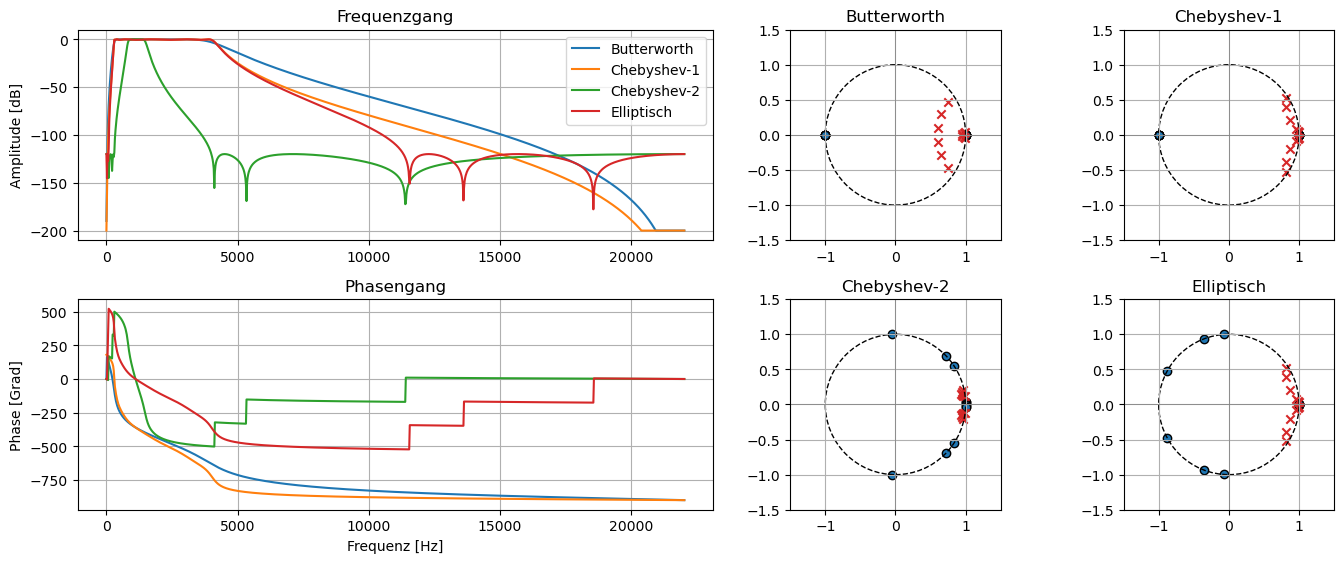

In [17]:
# Plot: Bandpassvergleich
fig_bp = plt.figure(figsize=(14, 8))
gs_bp = fig_bp.add_gridspec(3, 4)

ax_mag_bp = fig_bp.add_subplot(gs_bp[0, :2])
ax_phase_bp = fig_bp.add_subplot(gs_bp[1, :2], sharex=ax_mag_bp)

# Subplots für Pol-/Nullstellen (2x2 rechts oben)
ax_pz1_bp = fig_bp.add_subplot(gs_bp[0, 2])
ax_pz2_bp = fig_bp.add_subplot(gs_bp[0, 3])
ax_pz3_bp = fig_bp.add_subplot(gs_bp[1, 2])
ax_pz4_bp = fig_bp.add_subplot(gs_bp[1, 3])

ax_mag_bp.plot(w_bp_bw, 20 * np.log10(np.maximum(np.abs(h_bp_bw),1e-10)), label='Butterworth')
ax_phase_bp.plot(w_bp_bw, np.unwrap(np.angle(h_bp_bw))*(180/np.pi), label = 'Butterworth')
ax_pz1_bp.scatter(np.real(z_bp_bw), np.imag(z_bp_bw), marker='o', edgecolor='k', facecolor='tab:blue')
ax_pz1_bp.scatter(np.real(p_bp_bw), np.imag(p_bp_bw), marker='x', color='tab:red')
ax_pz1_bp.add_patch(patches.Circle((0, 0), 1, fill=False, color='black', linestyle='--'))
ax_pz1_bp.set_title("Butterworth")

ax_mag_bp.plot(w_bp_c1, 20 * np.log10(np.maximum(np.abs(h_bp_c1),1e-10)), label='Chebyshev-1')
ax_phase_bp.plot(w_bp_c1, np.unwrap(np.angle(h_bp_c1))*(180/np.pi), label = 'Chebyshev-1')
ax_pz2_bp.scatter(np.real(z_bp_c1), np.imag(z_bp_c1), marker='o', edgecolor='k', facecolor='tab:blue')
ax_pz2_bp.scatter(np.real(p_bp_c1), np.imag(p_bp_c1), marker='x', color='tab:red')
ax_pz2_bp.add_patch(patches.Circle((0, 0), 1, fill=False, color='black', linestyle='--'))
ax_pz2_bp.set_title("Chebyshev-1")

ax_mag_bp.plot(w_bp_c2, 20 * np.log10(np.maximum(np.abs(h_bp_c2),1e-10)), label='Chebyshev-2')
ax_phase_bp.plot(w_bp_c2, np.unwrap(np.angle(h_bp_c2))*(180/np.pi), label = 'Chebyshev-2')
ax_pz3_bp.scatter(np.real(z_bp_c2), np.imag(z_bp_c2), marker='o', edgecolor='k', facecolor='tab:blue')
ax_pz3_bp.scatter(np.real(p_bp_c2), np.imag(p_bp_c2), marker='x', color='tab:red')
ax_pz3_bp.add_patch(patches.Circle((0, 0), 1, fill=False, color='black', linestyle='--'))
ax_pz3_bp.set_title("Chebyshev-2")

ax_mag_bp.plot(w_bp_ep, 20 * np.log10(np.maximum(np.abs(h_bp_ep),1e-10)), label='Elliptisch')
ax_phase_bp.plot(w_bp_ep, np.unwrap(np.angle(h_bp_ep))*(180/np.pi), label = 'Elliptisch')
ax_pz4_bp.scatter(np.real(z_bp_ep), np.imag(z_bp_ep), marker='o', edgecolor='k', facecolor='tab:blue')
ax_pz4_bp.scatter(np.real(p_bp_ep), np.imag(p_bp_ep), marker='x', color='tab:red')
ax_pz4_bp.add_patch(patches.Circle((0, 0), 1, fill=False, color='black', linestyle='--'))
ax_pz4_bp.set_title("Elliptisch")

# Einstellungen für alle Subplots
for ax_bp in [ax_pz1_bp, ax_pz2_bp, ax_pz3_bp, ax_pz4_bp]:
    ax_bp.axhline(0, color='gray', lw=0.5)
    ax_bp.axvline(0, color='gray', lw=0.5)
    ax_bp.set_xlim([-1.5, 1.5])
    ax_bp.set_ylim([-1.5, 1.5])
    ax_bp.set_aspect('equal')
    ax_bp.grid(True)

# Frequenz- und Phasengang
ax_mag_bp.set_title("Frequenzgang")
ax_mag_bp.set_ylabel("Amplitude [dB]")
ax_mag_bp.grid(True)
ax_mag_bp.legend()

ax_phase_bp.set_title("Phasengang")
ax_phase_bp.set_ylabel("Phase [Grad]")
ax_phase_bp.set_xlabel("Frequenz [Hz]")
ax_phase_bp.grid(True)

plt.tight_layout()
plt.show()

In [18]:
# Butter Bandstop Filterentwurf
b_bs_bw, a_bs_bw = butter(N=order_b, Wn=wn_b, btype='bandstop', analog=False)
z_bs_bw, p_bs_bw, k_bs_bw = butter(N=order_b, Wn=wn_b, btype='bandstop', analog=False, output='zpk')
sos_bs_bw = butter(N=order_b, Wn=wn_b, btype='bandstop', analog=False, output='sos')

# Frequenzgang berechnen
w_bs_bw, h_bs_bw = freqz(b_bs_bw, a_bs_bw, worN=1024, fs=fs)

# Koeffizienten
print('Butterworth-Bandstop')
print('b Koeffizienten:', b_bs_bw)
print('a Koeffizienten:', a_bs_bw)
print('SOS-Matrix:')
for i, section in enumerate(sos_bs_bw):
    print(f"Section {i + 1}: {section}")

Butterworth-Bandstop
b Koeffizienten: [   0.3556982    -4.21526128   22.94821498  -75.88966391  169.78843873
 -270.74182265  315.50879187 -270.74182265  169.78843873  -75.88966391
   22.94821498   -4.21526128    0.3556982 ]
a Koeffizienten: [ 1.00000000e+00 -9.84346993e+00  4.45777233e+01 -1.22866900e+02
  2.29638401e+02 -3.06691958e+02  3.00182773e+02 -2.16986283e+02
  1.14973093e+02 -4.35515709e+01  1.11949851e+01 -1.75331379e+00
  1.26521229e-01]
SOS-Matrix:
Section 1: [ 0.3556982  -0.70254355  0.3556982   1.         -1.21671148  0.38036491]
Section 2: [ 1.         -1.97511133  1.          1.         -1.29346055  0.5040771 ]
Section 3: [ 1.         -1.97511133  1.          1.         -1.50645476  0.78464653]
Section 4: [ 1.         -1.97511133  1.          1.         -1.90714666  0.90952103]
Section 5: [ 1.         -1.97511133  1.          1.         -1.94072539  0.94274752]
Section 6: [ 1.         -1.97511133  1.          1.         -1.97897111  0.98080753]


In [19]:
# Cheby1 Bandstop Filterentwurf
b_bs_c1, a_bs_c1 = cheby1(N=order_b, rp=rp, Wn=wn_b, btype='bandstop', analog=False)
z_bs_c1, p_bs_c1, k_bs_c1 = cheby1(N=order_b, rp=rp, Wn=wn_b, btype='bandstop', analog=False, output='zpk')
sos_bs_c1 = cheby1(N=order_b, rp=rp, Wn=wn_b, btype='bandstop', analog=False, output='sos')

# Frequenzgang berechnen
w_bs_c1, h_bs_c1 = freqz(b_bs_c1, a_bs_c1, worN=1024, fs=fs)

# Koeffizienten
print('Chebychev1-Bandstop')
print('b Koeffizienten:', b_bs_c1)
print('a Koeffizienten:', a_bs_c1)
print('SOS-Matrix:')
for i, section in enumerate(sos_bs_c1):
    print(f"Section {i + 1}: {section}")

Chebychev1-Bandstop
b Koeffizienten: [   0.26190134   -3.10370584   16.89681947  -55.87772084  125.01558831
 -199.34777947  232.30979405 -199.34777947  125.01558831  -55.87772084
   16.89681947   -3.10370584    0.26190134]
a Koeffizienten: [ 1.00000000e+00 -9.31941390e+00  4.00451602e+01 -1.05016111e+02
  1.87391016e+02 -2.40008991e+02  2.26677722e+02 -1.59548585e+02
  8.34740073e+01 -3.19094528e+01  8.56023607e+00 -1.46979406e+00
  1.24205966e-01]
SOS-Matrix:
Section 1: [ 0.26190134 -0.51728431  0.26190134  1.         -0.4319558   0.19516675]
Section 2: [ 1.         -1.97511133  1.          1.         -1.3074534   0.71766914]
Section 3: [ 1.         -1.97511133  1.          1.         -1.63218784  0.93163903]
Section 4: [ 1.         -1.97511133  1.          1.         -1.97360612  0.97393603]
Section 5: [ 1.         -1.97511133  1.          1.         -1.98176915  0.98291531]
Section 6: [ 1.         -1.97511133  1.          1.         -1.9924416   0.9943016 ]


In [20]:
# Cheby2 Bandstop Filterentwurf
b_bs_c2, a_bs_c2 = cheby2(N=order_b, rs=rs, Wn=wn_b, btype='bandstop', analog=False)
z_bs_c2, p_bs_c2, k_bs_c2 = cheby2(N=order_b, rs=rs, Wn=wn_b, btype='bandstop', analog=False, output='zpk')
sos_bs_c2 = cheby2(N=order_b, rs=rs, Wn=wn_b, btype='bandstop', analog=False, output='sos')

# Frequenzgang berechnen
w_bs_c2, h_bs_c2 = freqz(b_bs_c2, a_bs_c2, worN=1024, fs=fs)

# Koeffizienten
print('Chebyshev2-Bandstop')
print('b Koeffizienten:', b_bs_c2)
print('a Koeffizienten:', a_bs_c2)
print('SOS-Matrix:')
for i, section in enumerate(sos_bs_c2):
    print(f"Section {i + 1}: {section}")

Chebyshev2-Bandstop
b Koeffizienten: [ 0.00811384 -0.09283358  0.49093757 -1.58703826  3.49320424 -5.51573255
  6.40669749 -5.51573255  3.49320424 -1.58703826  0.49093757 -0.09283358
  0.00811384]
a Koeffizienten: [ 1.         -4.41122911  7.24207799 -5.68642993  3.62291687 -3.79651557
  2.46413937 -0.27353488  0.04183205 -0.25647834  0.01242484  0.03297905
  0.00781767]
SOS-Matrix:
Section 1: [ 0.00811384 -0.01575385  0.00811384  1.          0.41339421  0.05930067]
Section 2: [ 1.         -1.81466568  1.          1.          0.48502604  0.21823851]
Section 3: [ 1.         -1.70083775  1.          1.          0.65872661  0.62347692]
Section 4: [ 1.         -1.98944423  1.          1.         -1.98406155  0.98412978]
Section 5: [ 1.         -1.99677511  1.          1.         -1.98850388  0.988571  ]
Section 6: [ 1.         -1.99806114  1.          1.         -1.99581054  0.99587669]


In [21]:
# Ellip Bandstop Filterentwurf
b_bs_ep, a_bs_ep = ellip(N=order_b, rp=rp, rs=rs, Wn=wn_b, btype='bandstop', analog=False)
z_bs_ep, p_bs_ep, k_bs_ep = ellip(N=order_b, rp=rp, rs=rs, Wn=wn_b, btype='bandstop', analog=False, output='zpk')
sos_bs_ep = ellip(N=order_b, rp=rp, rs=rs, Wn=wn_b, btype='bandstop', analog=False, output='sos')

# Frequenzgang berechnen
w_bs_ep, h_bs_ep = freqz(b_bs_ep, a_bs_ep, worN=1024, fs=fs)

# Koeffizienten
print('Elliptischer Bandstop')
print('b Koeffizienten:', b_bs_ep)
print('a Koeffizienten:', a_bs_ep)
print('SOS-Matrix:')
for i, section in enumerate(sos_bs_ep):
    print(f"Section {i + 1}: {section}")

Elliptischer Bandstop
b Koeffizienten: [   0.26974244   -3.1886112    17.32338358  -57.19671374  127.82021701
 -203.68002934  237.30402253 -203.68002934  127.82021701  -57.19671374
   17.32338358   -3.1886112     0.26974244]
a Koeffizienten: [ 1.00000000e+00 -9.35203348e+00  4.03373432e+01 -1.06211251e+02
  1.90340046e+02 -2.44889321e+02  2.32367274e+02 -1.64317033e+02
  8.63461192e+01 -3.31265291e+01  8.90497916e+00 -1.52825258e+00
  1.28658549e-01]
SOS-Matrix:
Section 1: [ 0.26974244 -0.53099987  0.26974244  1.         -0.45208709  0.1998374 ]
Section 2: [ 1.         -1.95350604  1.          1.         -1.31806418  0.72417086]
Section 3: [ 1.         -1.94261741  1.          1.         -1.63404801  0.93398109]
Section 4: [ 1.         -1.9803143   1.          1.         -1.97321487  0.97355668]
Section 5: [ 1.         -1.9867106   1.          1.         -1.98197362  0.98313805]
Section 6: [ 1.         -1.98925513  1.          1.         -1.99264572  0.99450511]


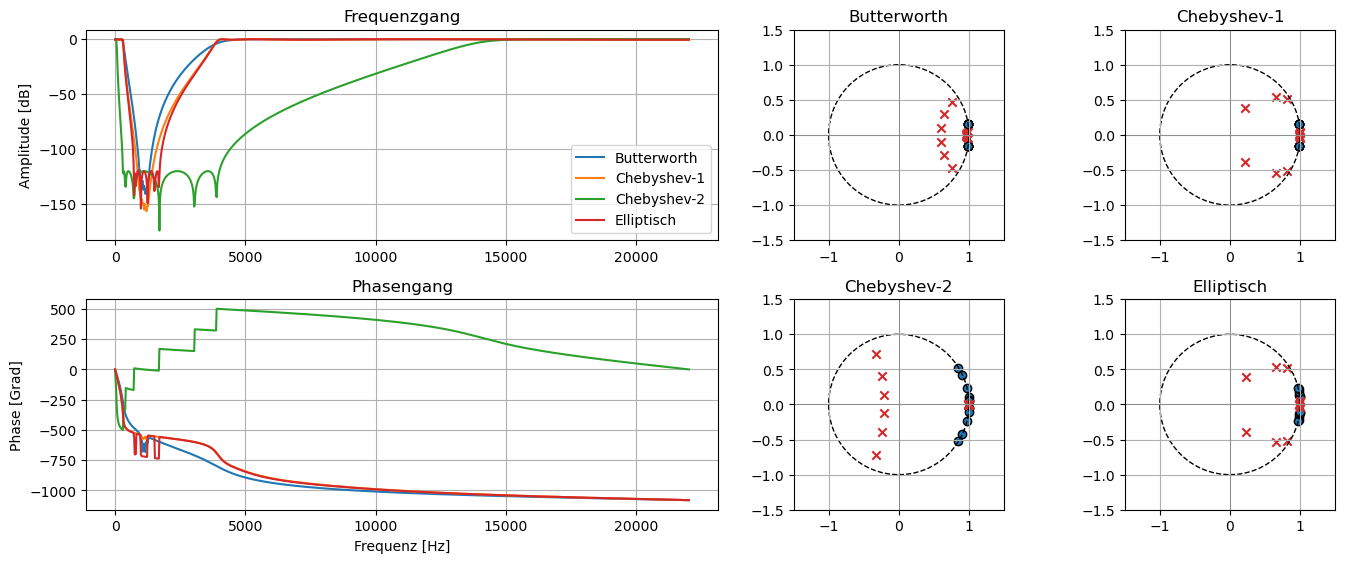

In [22]:
# Plot: Bandstopvergleich
fig_bs = plt.figure(figsize=(14, 8))
gs_bs = fig_bs.add_gridspec(3, 4)

ax_mag_bs = fig_bs.add_subplot(gs_bs[0, :2])
ax_phase_bs = fig_bs.add_subplot(gs_bs[1, :2], sharex=ax_mag_bs)

# Subplots für Pol-/Nullstellen (2x2 rechts oben)
ax_pz1_bs = fig_bs.add_subplot(gs_bs[0, 2])
ax_pz2_bs = fig_bs.add_subplot(gs_bs[0, 3])
ax_pz3_bs = fig_bs.add_subplot(gs_bs[1, 2])
ax_pz4_bs = fig_bs.add_subplot(gs_bs[1, 3])

ax_mag_bs.plot(w_bs_bw, 20 * np.log10(np.maximum(np.abs(h_bs_bw),1e-10)), label='Butterworth')
ax_phase_bs.plot(w_bs_bw, np.unwrap(np.angle(h_bs_bw))*(180/np.pi), label = 'Butterworth')
ax_pz1_bs.scatter(np.real(z_bs_bw), np.imag(z_bs_bw), marker='o', edgecolor='k', facecolor='tab:blue')
ax_pz1_bs.scatter(np.real(p_bs_bw), np.imag(p_bs_bw), marker='x', color='tab:red')
ax_pz1_bs.add_patch(patches.Circle((0, 0), 1, fill=False, color='black', linestyle='--'))
ax_pz1_bs.set_title("Butterworth")

ax_mag_bs.plot(w_bs_c1, 20 * np.log10(np.maximum(np.abs(h_bs_c1),1e-10)), label='Chebyshev-1')
ax_phase_bs.plot(w_bs_c1, np.unwrap(np.angle(h_bs_c1))*(180/np.pi), label = 'Chebyshev-1')
ax_pz2_bs.scatter(np.real(z_bs_c1), np.imag(z_bs_c1), marker='o', edgecolor='k', facecolor='tab:blue')
ax_pz2_bs.scatter(np.real(p_bs_c1), np.imag(p_bs_c1), marker='x', color='tab:red')
ax_pz2_bs.add_patch(patches.Circle((0, 0), 1, fill=False, color='black', linestyle='--'))
ax_pz2_bs.set_title("Chebyshev-1")

ax_mag_bs.plot(w_bs_c2, 20 * np.log10(np.maximum(np.abs(h_bs_c2),1e-10)), label='Chebyshev-2')
ax_phase_bs.plot(w_bs_c2, np.unwrap(np.angle(h_bs_c2))*(180/np.pi), label = 'Chebyshev-2')
ax_pz3_bs.scatter(np.real(z_bs_c2), np.imag(z_bs_c2), marker='o', edgecolor='k', facecolor='tab:blue')
ax_pz3_bs.scatter(np.real(p_bs_c2), np.imag(p_bs_c2), marker='x', color='tab:red')
ax_pz3_bs.add_patch(patches.Circle((0, 0), 1, fill=False, color='black', linestyle='--'))
ax_pz3_bs.set_title("Chebyshev-2")

ax_mag_bs.plot(w_bs_ep, 20 * np.log10(np.maximum(np.abs(h_bs_ep),1e-10)), label='Elliptisch')
ax_phase_bs.plot(w_bs_ep, np.unwrap(np.angle(h_bs_ep))*(180/np.pi), label = 'Elliptisch')
ax_pz4_bs.scatter(np.real(z_bs_ep), np.imag(z_bs_ep), marker='o', edgecolor='k', facecolor='tab:blue')
ax_pz4_bs.scatter(np.real(p_bs_ep), np.imag(p_bs_ep), marker='x', color='tab:red')
ax_pz4_bs.add_patch(patches.Circle((0, 0), 1, fill=False, color='black', linestyle='--'))
ax_pz4_bs.set_title("Elliptisch")

# Einstellungen für alle Subplots
for ax_bs in [ax_pz1_bs, ax_pz2_bs, ax_pz3_bs, ax_pz4_bs]:
    ax_bs.axhline(0, color='gray', lw=0.5)
    ax_bs.axvline(0, color='gray', lw=0.5)
    ax_bs.set_xlim([-1.5, 1.5])
    ax_bs.set_ylim([-1.5, 1.5])
    ax_bs.set_aspect('equal')
    ax_bs.grid(True)

# Frequenz- und Phasengang
ax_mag_bs.set_title("Frequenzgang")
ax_mag_bs.set_ylabel("Amplitude [dB]")
ax_mag_bs.grid(True)
ax_mag_bs.legend()

ax_phase_bs.set_title("Phasengang")
ax_phase_bs.set_ylabel("Phase [Grad]")
ax_phase_bs.set_xlabel("Frequenz [Hz]")
ax_phase_bs.grid(True)

plt.tight_layout()
plt.show()